In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")

In [27]:
features = pd.read_csv('data/raw/ecommerce_customer_features.csv')
targets = pd.read_csv('data/raw/ecommerce_customer_targets.csv')

In [28]:
features.head(),
targets.head()

,Customer_ID,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,No
4,43f81935-49e3-44d3-94d1-5c4715738988,No


In [29]:
df = pd.merge(features, targets, on='Customer_ID', how='inner')
df.head()

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   str    
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   str    
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score           

In [31]:
df.describe()

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,30.806667,80.487945,8.56750,29.598167,0.285057,0.071519,0.857667,3.076683,0.602106,3.879603,4.883687,8.069722,4.513517
std,17.358115,55.044707,9.88833,29.452645,0.158112,0.065077,0.977702,1.893899,0.201053,0.776396,1.479473,1.241928,1.150608
min,1.000000,10.000000,1.00000,0.000000,0.003000,0.000000,0.000000,0.000000,0.032000,1.000000,1.000000,2.300000,1.000000
25%,16.000000,44.525000,1.00000,9.000000,0.162000,0.022400,0.000000,1.600000,0.455000,3.350000,4.080000,7.320000,3.600000
50%,31.000000,67.225000,5.00000,20.000000,0.265000,0.052800,1.000000,3.000000,0.615000,3.920000,5.120000,8.230000,4.400000
75%,46.000000,100.685000,13.00000,41.000000,0.387000,0.102400,1.000000,4.400000,0.763000,4.490000,5.930000,9.000000,5.200000
max,60.000000,1006.530000,85.00000,261.000000,0.895000,0.493600,6.000000,10.300000,0.999000,5.000000,8.720000,10.000000,8.600000


In [32]:
df.isnull().sum()

Customer_ID                    0
account_age_months             0
avg_order_value                0
total_orders                   0
days_since_last_purchase       0
discount_usage_rate            0
return_rate                    0
customer_support_tickets       0
loyalty_member                 0
browsing_frequency_per_week    0
cart_abandonment_rate          0
product_review_score_avg       0
engagement_score               0
satisfaction_score             0
price_sensitivity_index        0
churned                        0
dtype: int64

In [33]:
df.fillna(df.median(numeric_only=True), inplace=True)

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,7e6f01d6-a7bb-429e-91d1-7c929547852b,2,77.48,1,22,0.066,0.0056,1,No,7.6,0.773,4.55,6.47,8.86,3.0,No
5996,4874448f-192d-4c5a-a21b-80d02b70c0e4,52,49.06,27,23,0.135,0.0224,0,No,1.1,0.863,5.00,5.12,9.93,3.7,No
5997,6a5b9ad3-7488-40e9-95b7-ad0ea7354f51,8,66.12,1,14,0.127,0.0352,0,No,1.5,0.732,3.23,4.83,8.11,3.5,No
5998,3306b81f-13df-4ae9-947d-deaaf7723279,4,103.95,3,1,0.231,0.0288,0,No,1.7,0.509,5.00,5.62,9.90,4.0,No


In [34]:
y = df['churned']
X = df.drop(['churned', 'Customer_ID'], axis=1)

In [35]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
obj_cols = X.select_dtypes(include=['object', 'string']).columns
X[obj_cols] = oe.fit_transform(X[obj_cols])

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Accuracy: 0.9675

Classification Report:
               precision    recall  f1-score   support

          No       0.97      0.99      0.98      1007
         Yes       0.94      0.85      0.89       193

    accuracy                           0.97      1200
   macro avg       0.96      0.92      0.94      1200
weighted avg       0.97      0.97      0.97      1200



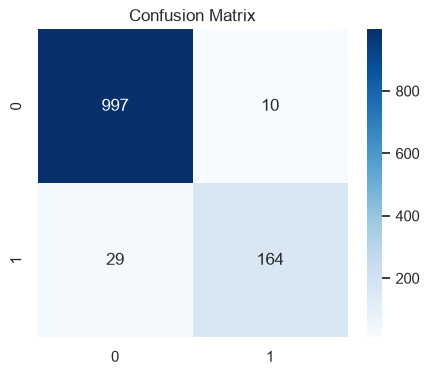

In [38]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

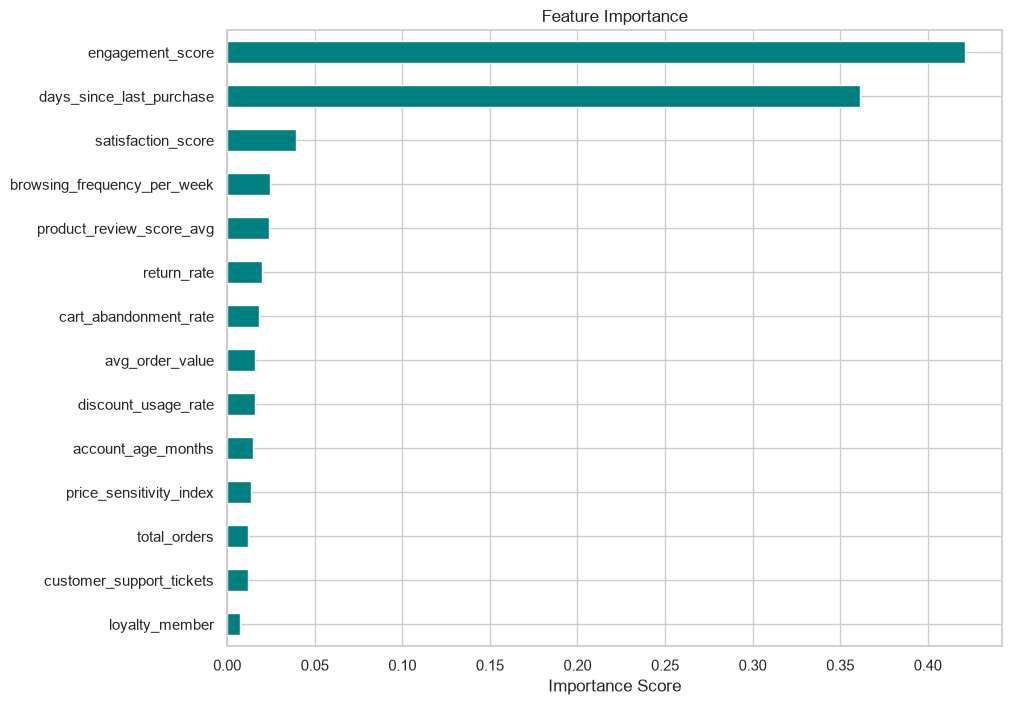

In [39]:
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(10,8))
importances.sort_values().plot(kind='barh', color='teal')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [42]:
def predict_churn(customer_data):
    data = pd.DataFrame([customer_data])
    data = data.drop(columns=['Customer_ID'], errors='ignore')

    categorical_cols = list(getattr(oe, 'feature_names_in_', []))
    if categorical_cols:
        data[categorical_cols] = oe.transform(data[categorical_cols])

    data = data.reindex(columns=X.columns, fill_value=0)
    return model.predict(data)[0]

In [44]:
customer = {
"account_age_months": 24,
"avg_order_value": 89.5,
"total_orders": 12,
"days_since_last_purchase": 18,
"discount_usage_rate": 0.35,
"return_rate": 0.08,
"customer_support_tickets": 1,
"loyalty_member": "Yes",
"browsing_frequency_per_week": 4.2,
"cart_abandonment_rate": 0.27,
"product_review_score_avg": 4.3,
"engagement_score": 6.8,
"satisfaction_score": 8.1,
"price_sensitivity_index": 5.4
}

prediction = predict_churn(customer)
print("Churn prediction:", prediction)

Churn prediction: No
